2024-06-27 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']


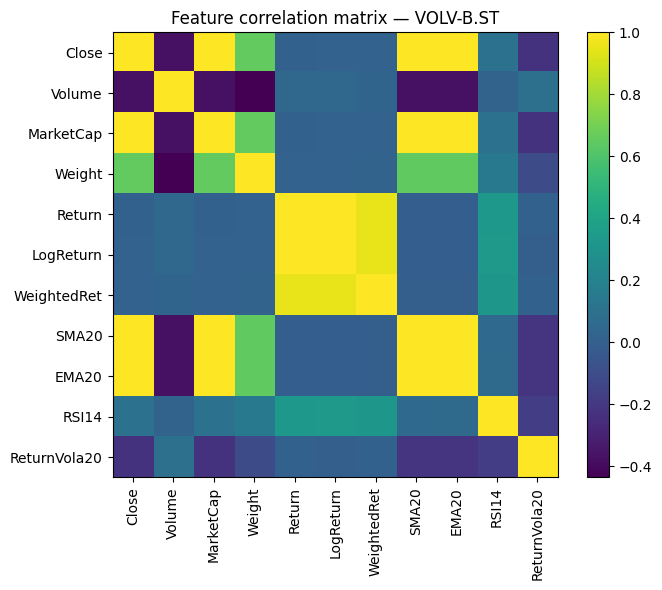

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-210*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "VOLV-B.ST"

ticker_df = df[df["Ticker"] == chosen_ticker]
corr_mat  = ticker_df[feature_cols].corr()


plt.figure(figsize=(8, 6))
im = plt.imshow(corr_mat, interpolation="none")   
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)

plt.title(f"Feature correlation matrix — {chosen_ticker}")
plt.tight_layout()
plt.show()

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40357/3157588299.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")       # forward-fill remaining gaps


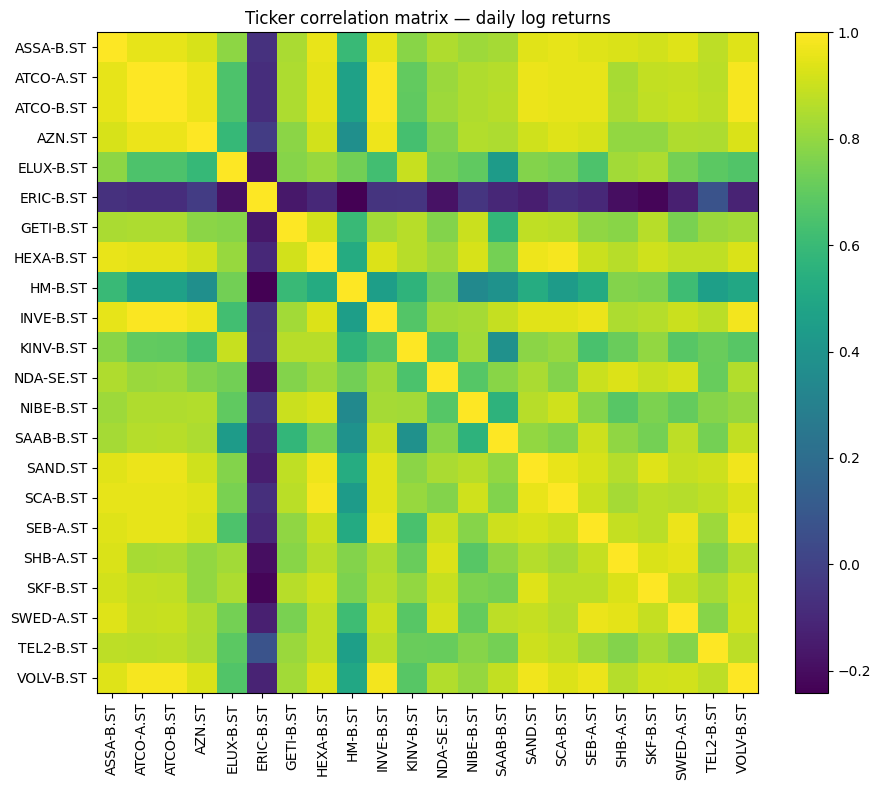

In [4]:
# ---------------- 2. Ticker correlations across ALL tickers ------------
# We’ll use LogReturn (typical for co-movement analysis).
pivot_ret = (
    df.pivot_table(values="Close", index=df.index, columns="Ticker")
      .dropna(how="all")            # drop dates where every ticker is NaN
      .fillna(method="ffill")       # forward-fill remaining gaps
)
ticker_corr = pivot_ret.corr()      # (tickers × tickers)

plt.figure(figsize=(10, 8))
im2 = plt.imshow(ticker_corr, interpolation="none")
plt.colorbar(im2, fraction=0.046, pad=0.04)
plt.xticks(range(len(ticker_corr.columns)), ticker_corr.columns, rotation=90)
plt.yticks(range(len(ticker_corr.columns)), ticker_corr.columns)
plt.title("Ticker correlation matrix — daily log returns")
plt.tight_layout()
plt.show()